In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from i308_utils import imshow, show_images

CALIBRACION DE LA CAMARA.

In [4]:
# Definición del checkerboard

checkerboard = (10, 7)
square_size_mm = 24.2


In [5]:
from utils.calib import board_points

# creamos los puntos del mundo del objeto checkerboard
checkerboard_world_points_mm = board_points(checkerboard) * square_size_mm


In [6]:
import glob, os

directory = os.path.join("datasets", "stereo_budha_charuco", "calib")
left_files_pattern = "*left*.jpg"
right_files_pattern = "*right*.jpg"

def numeric_sort(file_name):
    return int(file_name.split("_")[-1].split(".")[0])

left_file_names = sorted(
    glob.glob(
        os.path.join(directory, left_files_pattern)
    ),
    key=numeric_sort
)

right_file_names = sorted(
    glob.glob(
        os.path.join(directory, right_files_pattern)
    ),
    key=numeric_sort
)

num_left = len(left_file_names)
num_right = len(right_file_names)

if  num_left != num_right:
    raise Exception(f"the number of files (left {num_left} / right{num_right}) doesn't match")

In [7]:
import cv2

image_size = None
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-3)

world_points = []
left_images = []
right_images = []
left_images_points = []
right_images_points = []

for left_file_name, right_file_name in zip(
    left_file_names, right_file_names
):

    print("processing", left_file_name, right_file_name)

    # read left and right images
    left_image = cv2.imread(left_file_name, cv2.IMREAD_GRAYSCALE)
    right_image = cv2.imread(right_file_name, cv2.IMREAD_GRAYSCALE)

    # get the images sizes
    left_size = (left_image.shape[1], left_image.shape[0])
    right_size = (right_image.shape[1], right_image.shape[0])

    # checks that images sizes match
    if left_size != right_size:
        raise Exception(f"left and right images sizes differ: left {left_size} / right {right_size}")
        
    if image_size is None:
        # remembers the images size
        image_size = left_size
    else:
        if image_size != left_size:
            raise Exception(f"there are images with different sizes: {image_size} vs {left_size}")

    # finds the checkerboard in each image
    left_found, left_corners = cv2.findChessboardCorners(left_image, checkerboard)
    right_found, right_corners = cv2.findChessboardCorners(right_image, checkerboard)

    if not left_found or not right_found:
        print("warning, checkerboard was not found")
        print("  left found:", left_found)
        print("  right found:", right_found)
        continue

    # checkerboard was found in both images.

    # let's improve the found corners
    corners_left = cv2.cornerSubPix(left_image, left_corners, (7, 7), (-1,-1), criteria)
    corners_right = cv2.cornerSubPix(right_image, right_corners, (7, 7), (-1,-1), criteria)

    # acumulo las imagenes
    left_images.append(left_image)
    right_images.append(right_image)

    # acumulo los corners detectados
    left_images_points.append(left_corners)
    right_images_points.append(right_corners)

    # acumulo los puntos del mundo
    world_points.append(checkerboard_world_points_mm)



processing datasets/stereo_budha_charuco/calib/left_1.jpg datasets/stereo_budha_charuco/calib/right_1.jpg
processing datasets/stereo_budha_charuco/calib/left_2.jpg datasets/stereo_budha_charuco/calib/right_2.jpg
processing datasets/stereo_budha_charuco/calib/left_3.jpg datasets/stereo_budha_charuco/calib/right_3.jpg
processing datasets/stereo_budha_charuco/calib/left_4.jpg datasets/stereo_budha_charuco/calib/right_4.jpg
processing datasets/stereo_budha_charuco/calib/left_5.jpg datasets/stereo_budha_charuco/calib/right_5.jpg
processing datasets/stereo_budha_charuco/calib/left_6.jpg datasets/stereo_budha_charuco/calib/right_6.jpg
processing datasets/stereo_budha_charuco/calib/left_7.jpg datasets/stereo_budha_charuco/calib/right_7.jpg
processing datasets/stereo_budha_charuco/calib/left_8.jpg datasets/stereo_budha_charuco/calib/right_8.jpg
processing datasets/stereo_budha_charuco/calib/left_9.jpg datasets/stereo_budha_charuco/calib/right_9.jpg
processing datasets/stereo_budha_charuco/calib

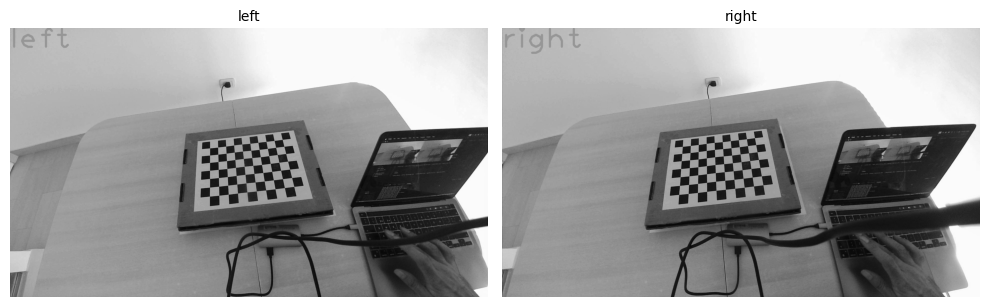

In [8]:
show_images([
    left_images[14], right_images[14]
], ['left', 'right'])

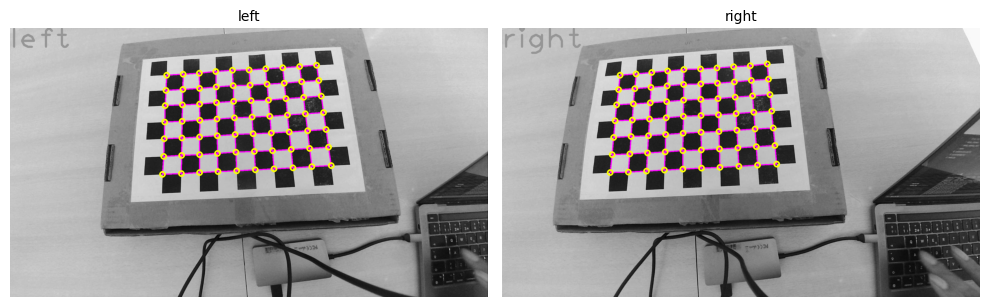

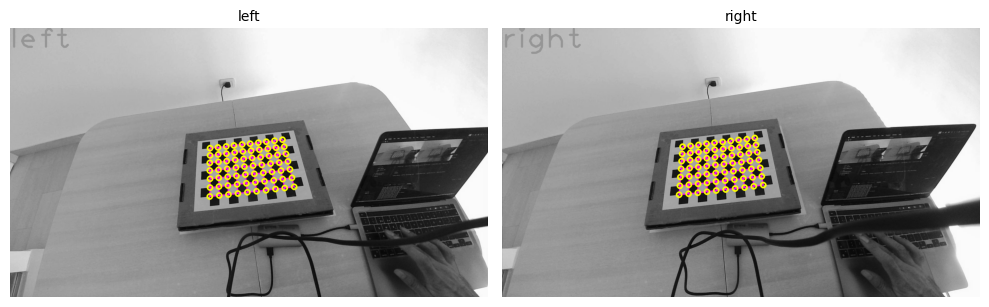

In [9]:
# grafiquemos algunos checkerboards
# y sus detecciones de corners
#  para verificar que lo que encontró está ok:

import utils.calib as calib
some_images_indices = [5, 14]

draw_settings = {
    "corner_radius": 10,
    "corner_thickness": 5,
    "line_thickness": 4
}
for i in some_images_indices:

    left_img, right_img = left_images[i], right_images[i]
    left_corners, right_corners = left_images_points[i], right_images_points[i]

    show_left = cv2.cvtColor(left_img, cv2.COLOR_GRAY2BGR)
    show_right = cv2.cvtColor(right_img, cv2.COLOR_GRAY2BGR)


    calib.draw_checkerboard(show_left, checkerboard, left_corners, True, **draw_settings)
    calib.draw_checkerboard(show_right, checkerboard, right_corners, True, **draw_settings)
    

    show_images([show_left, show_right], ["left", "right"])

In [10]:
# Calibramos Stereo

print("Calibrating Stereo")
print("num images:", len(left_images_points))

err, left_K, left_dist, right_K, right_dist, R, T, E, F = cv2.stereoCalibrate(
    world_points, 
    left_images_points, 
    right_images_points, 
    None, 
    None, 
    None, 
    None, 
    image_size, 
    flags=0
)

Calibrating Stereo
num images: 20


In [11]:
from utils.calib import np_print

to_print = [

    "# Left camera Intrinsics:",
    ("left_K", left_K),
    ("left_dist", left_dist),

    "# Right camera Intrinsics:",
    ("right_K", right_K),
    ("right_dist", right_dist),

    "# Rotation:",
    ("R", R),

    "# Translation:",
    ("T", T),
    
    "# Essential Matrix:",
    ("E", E),
    
    "# Fundamental Matrix:",
    ("F", F),
        
]

In [12]:
print("# STEREO CALIBRATION")
for line in to_print:

    if isinstance(line, str):   
        print(line)
    else:
        var_name, np_array = line
        print(f"{var_name} = {np_print(np_array)}\n")

# STEREO CALIBRATION
# Left camera Intrinsics:
left_K = np.array([
	[   600.327,	     0.000,	   951.211],
	[     0.000,	   600.963,	   540.742],
	[     0.000,	     0.000,	     1.000]
])

left_dist = np.array([
	[  0.016081,	 -0.032253,	 -0.001851,	 -0.000004,	  0.005872]
])

# Right camera Intrinsics:
right_K = np.array([
	[   600.076,	     0.000,	   951.911],
	[     0.000,	   600.698,	   527.573],
	[     0.000,	     0.000,	     1.000]
])

right_dist = np.array([
	[  0.016537,	 -0.032190,	 -0.001723,	  0.000880,	  0.005626]
])

# Rotation:
R = np.array([
	[     1.000,	     0.001,	     0.002],
	[    -0.001,	     1.000,	     0.010],
	[    -0.002,	    -0.010,	     1.000]
])

# Translation:
T = np.array([
	[-59.951193],
	[  0.203334],
	[  0.296358]
])

# Essential Matrix:
E = np.array([
	[    -0.000,	    -0.298,	     0.200],
	[     0.198,	    -0.616,	    59.948],
	[    -0.151,	   -59.948,	    -0.617]
])

# Fundamental Matrix:
F = np.array([
	[     0.000,	     0.000,	    -0.019],
	[    -0.0

In [13]:
# serializamos los resultados en un pickle
import pickle

calibration_results = {
    'left_K': left_K,
    'left_dist': left_dist,
    'right_K': right_K,
    'right_dist': right_dist,
    'R': R,
    'T': T,
    'E': E,
    'F': F,
    'image_size': image_size,
}

calibration_file = os.path.join("datasets","stereo_budha_charuco", "stereo_calibration.pkl")
with open(calibration_file, "wb") as f:
    f.write(pickle.dumps(calibration_results))
        


RECTIFICACION

In [14]:
R1, R2, P1, P2, Q, validRoi1, validRoi2 = cv2.stereoRectify(
    left_K, left_dist, right_K, right_dist, image_size, R, T, alpha=0
)

In [15]:
# calculemos los mapas de des-distorsión-rectificación:

left_map_x, left_map_y = cv2.initUndistortRectifyMap(left_K, left_dist, R1, P1, image_size, cv2.CV_32FC1)
right_map_x, right_map_y = cv2.initUndistortRectifyMap(right_K, right_dist, R2, P2, image_size, cv2.CV_32FC1)

In [16]:
# Qué pinta tienen estos mapas?
# chequeemos el shape, debería coincidir con image_size
left_map_x.shape

(1080, 1920)

In [17]:
# Qué valores contiene?
# en este caso son floats, por lo que se necesitará alguna forma de interpolación
left_map_x[0:3, 0:3]

array([[72.48674 , 73.373184, 74.25832 ],
       [72.491165, 73.37682 , 74.261185],
       [72.49516 , 73.38004 , 74.263626]], dtype=float32)

In [18]:
# tomemos un par estéreo
image_index = 5

left_image = left_images[image_index]
right_image = right_images[image_index]

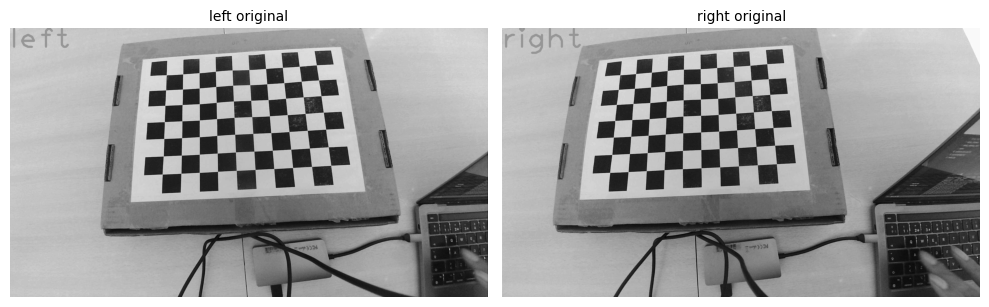

In [19]:
# muestro las imagenes:
show_images([
    left_image, right_image
], [
    "left original", "right original"
])


In [20]:
# aplicamos des-distorsion + rectificación, con los mapas que calculamos ateriormente
left_image_rectified = cv2.remap(left_image, left_map_x, left_map_y, cv2.INTER_LINEAR)
right_image_rectified = cv2.remap(right_image, right_map_x, right_map_y, cv2.INTER_LINEAR)

In [21]:
import numpy as np

# Ejemplo, para saber qué valor poner en la posición (i,j) de la imagen destino,
# a cuál píxel en la imagen original tendríamos que ir buscar?
x_dest, y_dest = 321, 123

x_ori = left_map_x[y_dest, x_dest]
y_ori = left_map_y[y_dest, x_dest]

x_ori = int(np.round(x_ori))
y_ori = int(np.round(y_ori))

print(f"using nearest neighbor interpolation, I_dest[{y_dest}, {x_dest}] = I_ori[{y_ori}, {x_ori}]")

print(left_image[y_ori, x_ori])
print(left_image_rectified[y_dest, x_dest])


using nearest neighbor interpolation, I_dest[123, 321] = I_ori[146, 330]
194
194


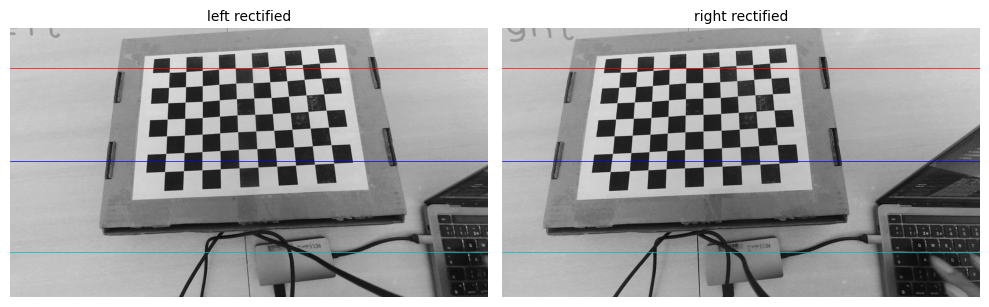

In [22]:
# muestro las imagenes stereo-rectificadas
# observar el vertice de la caja, de la notebook, y del cuaderno. 
# coinciden perfectamente en y.
from matplotlib import pyplot as plt 

fig, axes = show_images([
    left_image_rectified, right_image_rectified
], [
    "left rectified", "right rectified"
], show=False)

for y, c in zip([160, 533, 900], ['r', 'b', 'c']):
    axes[0].axhline(y=y, color=c, linestyle='-', linewidth=0.5)
    axes[1].axhline(y=y, color=c, linestyle='-', linewidth=0.5)
plt.show()

In [23]:
# Guardemos los resultados de rectificación para usar posteriormente:

stereo_maps = {

    # undistorting maps
    "left_map_x": left_map_x,
    "left_map_y": left_map_y,
    "right_map_x": right_map_x,
    "right_map_y": right_map_y,

    # add also rectifying info:
    "R1": R1,
    "R2": R2,
    "P1": P1,
    "P2": P2,
    "Q": Q,
    "validRoi1": validRoi1,
    "validRoi2": validRoi2,

}

stereo_maps_file = os.path.join("datasets","stereo_budha_charuco", "stereo_rectification_maps.pkl")
with open(stereo_maps_file, "wb") as f:
    f.write(pickle.dumps(stereo_maps))
        

In [24]:
import os

left_image_file = os.path.join("datasets","stereo_budha_charuco", "captures", "left_10.jpg")
right_image_file = os.path.join("datasets","stereo_budha_charuco", "captures", "right_10.jpg")

left_image = cv2.imread(left_image_file, 0)
right_image = cv2.imread(right_image_file, 0)

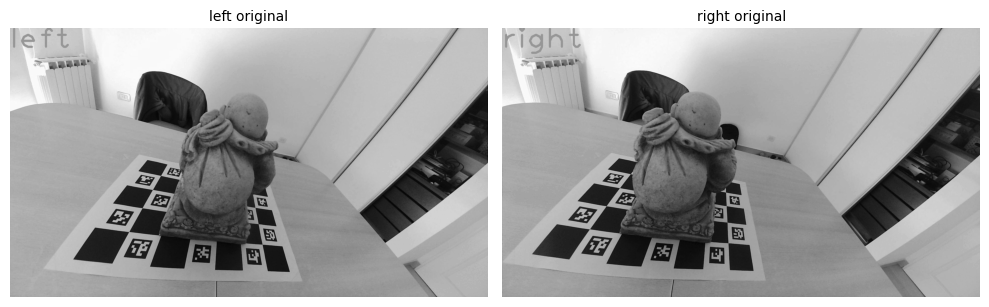

In [25]:

fig, axes = show_images([
    left_image, right_image
], [
    "left original", "right original"
], show=False)



In [26]:

import pickle


stereo_calib_file = os.path.join("datasets","stereo_budha_charuco", "stereo_calibration.pkl")
stereo_maps_file = os.path.join("datasets","stereo_budha_charuco", "stereo_rectification_maps.pkl")

print("reading stereo calibration results...")
with open(stereo_calib_file, "rb") as f:
    calibration = pickle.loads(f.read())
    
print("reading stereo rectification maps...")
with open(stereo_maps_file, "rb") as f:
    maps = pickle.loads(f.read())

reading stereo calibration results...
reading stereo rectification maps...


In [27]:
left_map_x, left_map_y = maps['left_map_x'], maps['left_map_y']
right_map_x, right_map_y = maps['right_map_x'], maps['right_map_y']

In [28]:

directory = os.path.join("datasets", "stereo_budha_charuco", "captures")
left_files_pattern = "*left*.jpg"
right_files_pattern = "*right*.jpg"


left_file_names = sorted(
    glob.glob(
        os.path.join(directory, left_files_pattern)
    ),
    key=numeric_sort
)

right_file_names = sorted(
    glob.glob(
        os.path.join(directory, right_files_pattern)
    ),
    key=numeric_sort
)

num_left = len(left_file_names)
num_right = len(right_file_names)

if  num_left != num_right:
    raise Exception(f"the number of files (left {num_left} / right{num_right}) doesn't match")

In [29]:


left_images_rectified = []
right_images_rectified = []

for left_file_name, right_file_name in zip(
    left_file_names, right_file_names
):

    print("processing", left_file_name, right_file_name)


    # read left and right images
    left_image = cv2.imread(left_file_name, cv2.IMREAD_GRAYSCALE)
    right_image = cv2.imread(right_file_name, cv2.IMREAD_GRAYSCALE)

    # apply rectification
    left_image_rectified = cv2.remap(left_image, left_map_x, left_map_y, cv2.INTER_LINEAR)
    right_image_rectified = cv2.remap(right_image, right_map_x, right_map_y, cv2.INTER_LINEAR)

    left_images_rectified.append(left_image_rectified)
    right_images_rectified.append(right_image_rectified)


    output_file = os.path.join("datasets", "stereo_budha_charuco","rectified","left", left_file_name)
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    cv2.imwrite(output_file, left_image_rectified)


    output_file = os.path.join("datasets", "stereo_budha_charuco","rectified","right", right_file_name)
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    cv2.imwrite(output_file, right_image_rectified)

    
    

processing datasets/stereo_budha_charuco/captures/left_0.jpg datasets/stereo_budha_charuco/captures/right_0.jpg
processing datasets/stereo_budha_charuco/captures/left_1.jpg datasets/stereo_budha_charuco/captures/right_1.jpg
processing datasets/stereo_budha_charuco/captures/left_2.jpg datasets/stereo_budha_charuco/captures/right_2.jpg
processing datasets/stereo_budha_charuco/captures/left_3.jpg datasets/stereo_budha_charuco/captures/right_3.jpg
processing datasets/stereo_budha_charuco/captures/left_4.jpg datasets/stereo_budha_charuco/captures/right_4.jpg
processing datasets/stereo_budha_charuco/captures/left_5.jpg datasets/stereo_budha_charuco/captures/right_5.jpg
processing datasets/stereo_budha_charuco/captures/left_6.jpg datasets/stereo_budha_charuco/captures/right_6.jpg
processing datasets/stereo_budha_charuco/captures/left_7.jpg datasets/stereo_budha_charuco/captures/right_7.jpg
processing datasets/stereo_budha_charuco/captures/left_8.jpg datasets/stereo_budha_charuco/captures/righ

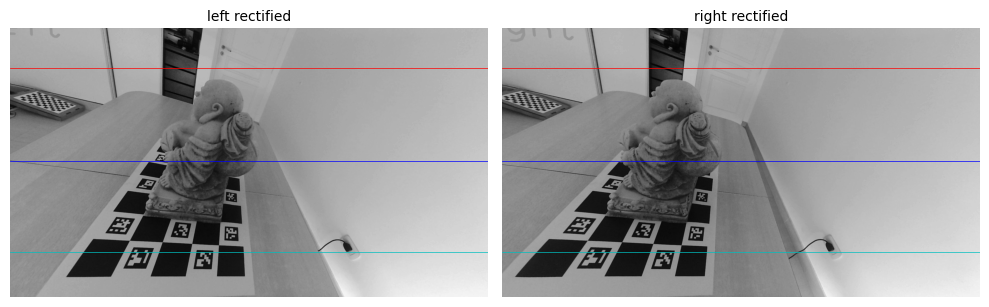

In [30]:
# tomemos un par estéreo
image_index = 6

# show images
fig, axes = show_images([
    left_images_rectified[image_index], right_images_rectified[image_index]
], [
    "left rectified", "right rectified"
], show=False)

for y, c in zip([160, 533, 900], ['r', 'b', 'c']):
    axes[0].axhline(y=y, color=c, linestyle='-', linewidth=0.5)
    axes[1].axhline(y=y, color=c, linestyle='-', linewidth=0.5)
plt.show()

DISPARIDAD


In [31]:
w, h = left_image.shape[1], left_image.shape[0]

fx = left_K[0][0]
fy = left_K[1][1]
cx0 = left_K[0][2]
cy0 = left_K[1][2]

baseline = np.linalg.norm(T)

In [35]:
# Cre Stereo

import cv2
import json
import numpy as np
from pathlib import Path

from utils.disparity.method_cre_stereo import CREStereo
from utils.disparity.methods import Calibration, InputPair, Config


calibration = Calibration(**{
    "width": w,
    "height": h,
    "baseline_meters": baseline / 1000,
    "fx": fx,
    "fy": fy,
    "cx0": cx0,
    "cx1": cx0,
    "cy": cy0,
    "depth_range": [0.05, 20.0],
    "left_image_rect_normalized": [0, 0, 1, 1]
})

In [36]:
import os

models_path = "models"
if not os.path.exists(models_path):
    os.makedirs(models_path)

In [37]:
#models_path = Path.home() / ".cache" / "stereodemo" / "models"
models_path = Path(models_path)
pair = InputPair(left_image_rectified, right_image_rectified, calibration)
# pair = InputPair(left_image, right_image, calibration)
config = Config(models_path=models_path)

# params = {
#    "Shape": "1280x720",
#    "Mode": "combined",
#    "Iterations": 20
#}
method = CREStereo(config)

#method.parameters["Shape"].set_value("640x480")
method.parameters["Shape"].set_value("1280x720")
# method.parameters["Iterations"].set_value("10")

#method.parameters.update(params)
# method = StereoBM(config)
# method = StereoSGBM(config)
# method = StereoBM(config)
disparity = method.compute_disparity(pair)

models/crestereo_combined_iter5_720x1280.onnx


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


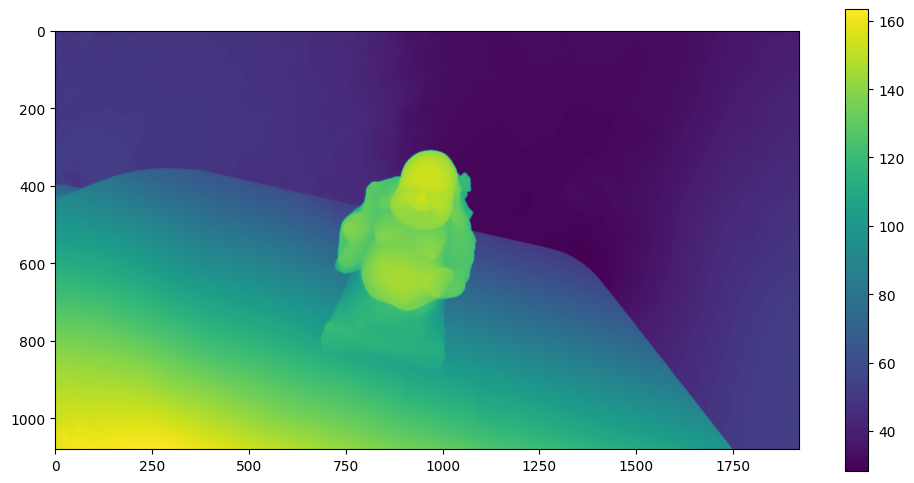

In [38]:
plt.figure(figsize=(12, 6))
plt.imshow(disparity.disparity_pixels)
plt.colorbar()
plt.show()